# Zadanie 2: optymalizacja z ograniczeniami

Termin realizacji: 31 marca 2025

Wybierz funkcję testową wykorzystaną w zadaniu 1.

Zadanie do oddania przez MS Teams. Do oddania: kod oraz krótkie sprawozdanie w PDF (można na przykład przy użyciu `quarto render notebook.ipynb --to pdf`).

## Na 3.0

Do realizacji:

1. Dodaj ograniczenie postaci $x_1^2 + x_2 + b = 0$ ze stałą $b$ dopasowaną w taki sposób, aby żadne minimum lokalne (przynajmniej w zakresie w którym losowany jest punkt początkowy) nie spełniają ograniczenia.
2. Zaimplementuj metodę funkcji kary do rozwiązania tego problemu.
3. Wylosuj 10 punktów z dziedziny przeszukiwania z tabelki. Dla każdego z nich przeprowadź 100 kroków optymalizacji metodą największego spadku ze stałym krokiem. Narysuj wykres zależności wartości funkcji optymalizowanej od kroku optymalizacji.
4. Przeprowadź procedurę dla kilku kroków. Spróbuj zilustrować brak zbieżności, szybką zbieżność i powolną zbieżność.

## Na 4.0

Do realizacji:

1. Punkty z zadania na 3.0.
2. Zamień metodę największego spadku na metodę gradientów sprzężonych.

## Na 5.0

Do realizacji:

1. Punkty z zadania na 4.0.
2. Wykonaj benchmarking metody z użyciem `BenchmarkTools.jl`. Zanotuj czasy działania wywołań optymalizacji oraz liczbę alokacji. Spróbuj zoptymalizować działanie funkcji korzystając wymienionych tu rad: [Julia performance tips](https://docs.julialang.org/en/v1/manual/performance-tips/). W sprawozdaniu napisz jakie zmiany wykonane i jak wpłynęły na czas działania programu.


In [1]:
using LinearAlgebra
using Plots
using Random

# 1. Funkcja z zad.1

In [2]:

function f(vec)
    x, y = vec[1], vec[2]
    return 2 * x^2 - 1.05 * x^4 + x^6 / 6 + x*y + y^2
end

function f_grad(vec)
    x, y = vec[1], vec[2]
    return [4 * x - 4.2 * x^3 + x^5 + y, x + 2 * y]
end

f_grad (generic function with 1 method)

In [3]:
function steepest_gradient_descent(cost, grad, x0, α; max_iter=100, tol=1e-8)
    θ = copy(x0)
    f_values = []
    storage = zeros(length(θ))
    for i in 1:max_iter
        value_start = cost(θ)
        storage = grad(θ)
        norm_storage = norm(storage)
        if norm_storage == 0
            break
        end
        θ_new = θ - storage .* (α / norm_storage)
        value_stop = cost(θ_new)
        push!(f_values, value_start)
        if abs(value_stop - value_start) < tol
            break
        else
            θ = θ_new
        end
    end
    return θ, f_values
end

steepest_gradient_descent (generic function with 1 method)

In [4]:
function rand_uniform(a, b)
    return rand() * (b-a) + a
end

# lista z 10 wylosowanymi punktami
points = [[rand_uniform(-5, 5), rand_uniform(-5, 5)] for i in 1:10]
points

10-element Vector{Vector{Float64}}:
 [-0.0533835220918677, 1.4728404707534093]
 [2.111957780181566, 2.7136523829701167]
 [3.8155476676326963, 3.813870933322548]
 [-1.7150946902903974, -2.835801356650146]
 [-3.837660848364867, 2.1204063335596004]
 [4.061986748141361, 2.847283624906537]
 [4.8782324256270435, -2.248489182530945]
 [-4.702819522097917, 1.2039957328854562]
 [-2.2838435507013655, -4.246619883851933]
 [-1.4425017197023937, -3.312863591112966]

In [5]:
function g(vec)
    b = 4
    x, y = vec[1], vec[2]
    return x^2 + y - 1
end

function g_grad(vec)
    x, y = vec[1], vec[2]
    return [2 * x, 1]
end

function p(vec)
    return g(vec)^2
end

function p_grad(vec)
    return 2 * g(vec) * g_grad(vec)
end

function fp(vec, ρ)
    return f(vec) + ρ * p(vec)
end

function fp_grad(vec, ρ)
    return f_grad(vec) + ρ * p_grad(vec)
end

fp_grad (generic function with 1 method)

In [15]:
function gradient_descent_with_penalty_method(fx, fx_grad, px, px_grad, fpx, fpx_grad, x0, k_max, α, ρ=1.0, γ=2.0, atol=1e-8, max_iter=100, tol=1e-6)
    x = x0
    θ = copy(x0)
    f_values = []
    p_values = []
    storage = zeros(length(θ))
    for k in 1 : k_max
        for i in 1:max_iter
            value_start = fpx(θ, ρ)
            storage = fpx_grad(θ, ρ)
            norm_storage = norm(storage)
            θ_new = θ - storage .* (α / norm_storage)
            value_stop = fpx(θ_new, ρ)
            push!(f_values, fx(θ))
            push!(p_values, px(θ))
            if abs(value_stop - value_start) < tol
                break
            else
                θ = θ_new
            end
        end
        x = θ
        ρ *= γ
        if p(x) < atol
            return x, f_values, p_values
        end
    end
    return x, f_values, p_values
end

gradient_descent_with_penalty_method (generic function with 6 methods)

In [11]:
x_min, fx_val, px_val = gradient_descent_with_penalty_method(f, f_grad, p, p_grad, fp, fp_grad, [0, 0], 16, 0.01)

([-0.5081523128642932, 0.7422753469264566], Any[0.0, 0.0001, 0.0003989796117408592, 0.0008953532275110312, 0.0015874593053465944, 0.002473557050537068, 0.0035518229653171457, 0.004820347267430691, 0.006277130179766872, 0.007920078095115279  …  0.6230528398326587, 0.6107174063475413, 0.6230582882613354, 0.6107226532682346, 0.6230637345348395, 0.6107278981976361, 0.6230691786455493, 0.6107331411281778, 0.6230746205858466, 0.610738382052296], Any[1, 0.9801, 0.9604002499951689, 0.9409012577241423, 0.9216035414873776, 0.9025076304164377, 0.8836140647657157, 0.8649233962277397, 0.8464361882730118, 0.8281530165150657  …  2.454760407418888e-7, 0.00018806615767931923, 2.45211189095132e-7, 0.00018806336275048284, 2.4494661624458626e-7, 0.00018806057221842083, 2.446823221670483e-7, 0.00018805778608165644, 2.444183068390027e-7, 0.00018805500433870698])

wykres f od iteracji, wykres p od iteracji

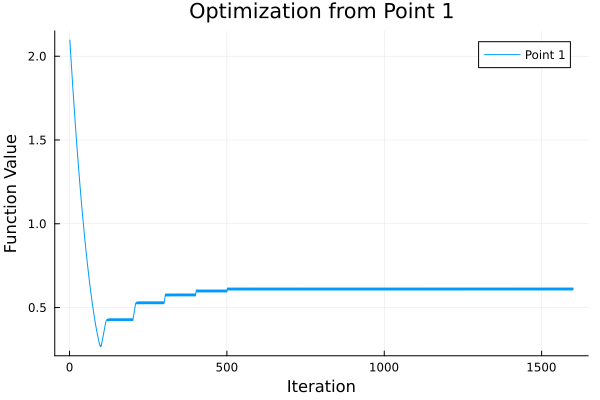

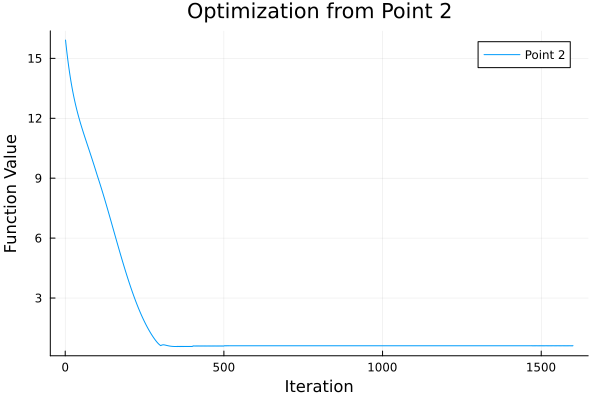

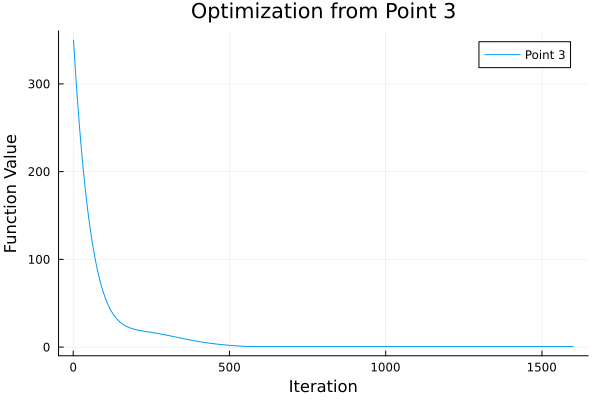

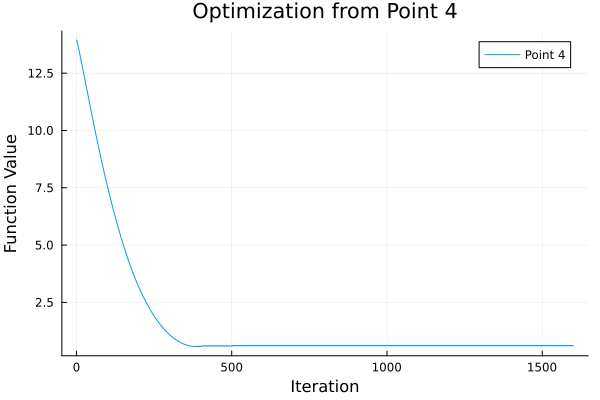

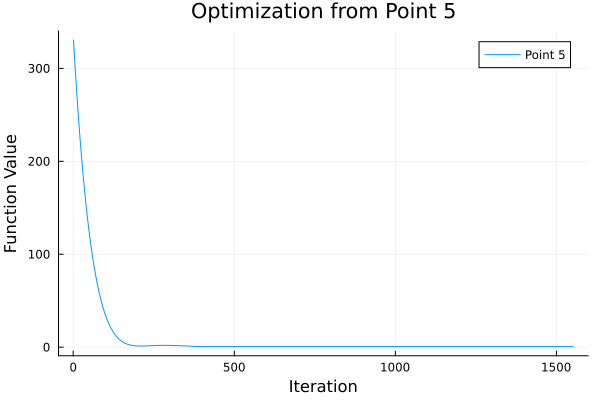

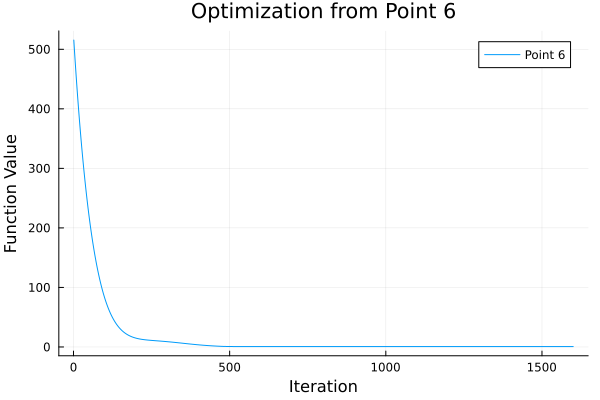

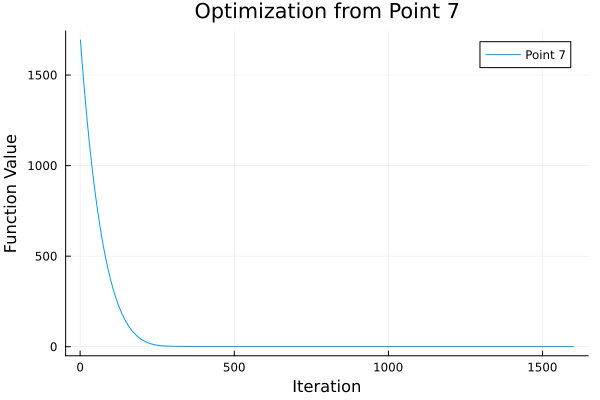

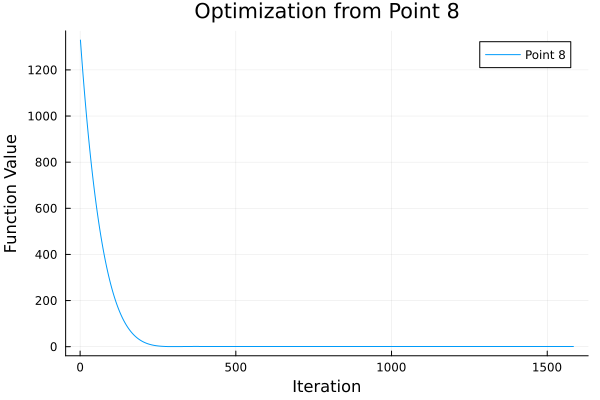

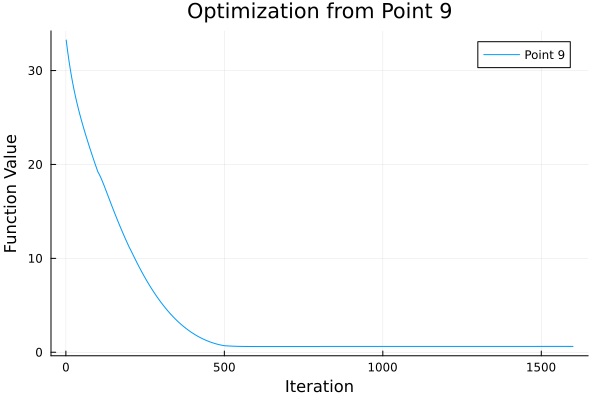

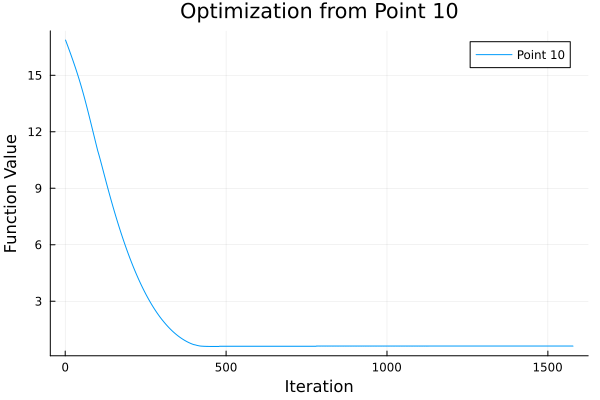

In [ ]:
for i in 1:10
    x_min, fx_val, px_val = gradient_descent_with_penalty_method(f, f_grad, p, p_grad, fp, fp_grad, points[i], 16, 0.01)
    plot(1:length(fx_val), fx_val, label="Point $i")
    plot(1:length(px_val), px_val, label="Point $i")
    display(plot!(title="Optimization from Point $i", xlabel="Iteration", ylabel="Function Value"))
end

In [70]:
points

10-element Vector{Vector{Float64}}:
 [-4.589618162298098, 1.068516675230601]
 [-3.6375850457679837, 0.9496926181795704]
 [-2.035107868252579, 3.632525278320349]
 [2.3401407015386138, 2.811321083447064]
 [-0.5517560524694654, 1.037246348315235]
 [-4.812921875187152, 2.2105592375883685]
 [1.9118833280052794, 1.010322092560072]
 [2.532333272969849, -0.5133379176085695]
 [-0.9137200056399184, 3.18139040996863]
 [4.883212074100435, 1.6398843687572633]